In [2]:
import sys
!{sys.executable} -m pip install scikit-learn pandas

In [3]:
import pandas as pd

# Dataset load karein
df = pd.read_csv('../week 3/clean_dataset.csv')

# Pehli 5 rows dekhein
df.head()

,Quote,Author,clean_text
0,“The world as we have created it is a process ...,Albert Einstein,The world as we have created it is a process o...
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,It is our choices Harry that show what we trul...
2,“There are only two ways to live your life. On...,Albert Einstein,There are only two ways to live your life One ...
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,The person be it gentleman or lady who has not...
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,Imperfection is beauty madness is genius and i...


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Null values check / drop karein (agar koi ho)
df = df.dropna(subset=['clean_text', 'Author'])

# 2. X (Features) aur y (Target variable) define karein
X = df['clean_text']
y = df['Author']

# 3. Text ko numbers mein convert karne ke liye TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)

print("Data successfully vectorized!")
print("Shape of feature matrix:", X_vectorized.shape)

Data successfully vectorized!
Shape of feature matrix: (100, 675)


In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Train aur Test split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# 2. Model initialize aur train karein
model = MultinomialNB()
model.fit(X_train, y_train)

# 3. Model test karein aur Accuracy check karein
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.1


In [6]:
# Naye quote ke author ko predict karne ka test
sample_quote = ["Life is what happens when you're busy making other plans."]

# 1. Quote ko vectorize karein
sample_vector = vectorizer.transform(sample_quote)

# 2. Prediction karein
predicted_author = model.predict(sample_vector)

print("Predicted Author:", predicted_author[0])

Predicted Author: J.K. Rowling


In [7]:
from sklearn.metrics import classification_report

# Detailed report print karein
print(classification_report(y_test, y_pred, zero_division=0))

                 precision    recall  f1-score   support

Albert Einstein       0.00      0.00      0.00         5
Alfred Tennyson       0.00      0.00      0.00         1
      Dr. Seuss       0.00      0.00      0.00         2
   George Eliot       0.00      0.00      0.00         1
   J.K. Rowling       0.10      1.00      0.18         2
    Jane Austen       0.00      0.00      0.00         1
    John Lennon       0.00      0.00      0.00         1
 Marilyn Monroe       0.00      0.00      0.00         3
     Mark Twain       0.00      0.00      0.00         1
  Mother Teresa       0.00      0.00      0.00         2
    W.C. Fields       0.00      0.00      0.00         1

       accuracy                           0.10        20
      macro avg       0.01      0.09      0.02        20
   weighted avg       0.01      0.10      0.02        20



In [9]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.2 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.5 MB 3.2 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.5 MB 3.2 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.5 MB 3.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 1.3 MB/s eta 0:00:07
   ----------- ---------------------------- 2.6/9.5 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.0 MB/s eta 0:00:04
   ------------- ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


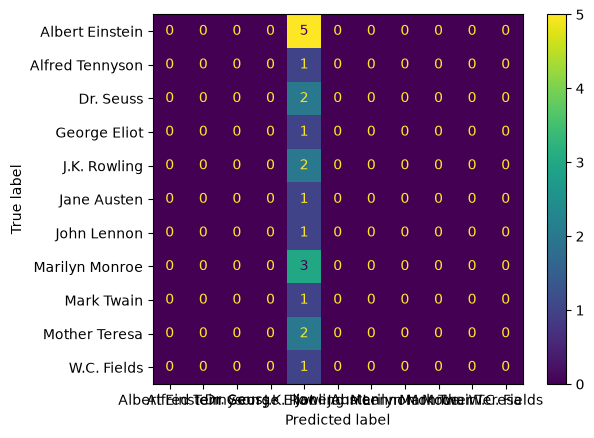

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

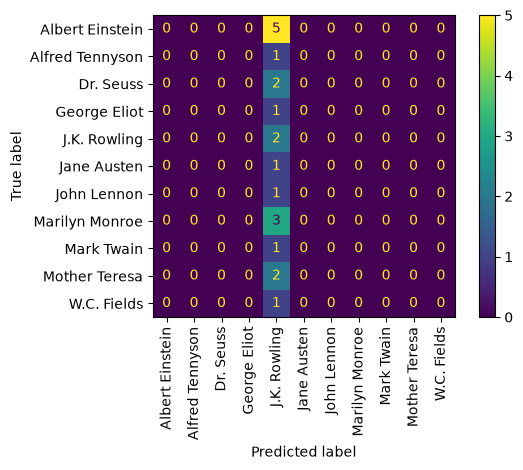

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()